# 스프린트 미션 15 — BMW 글로벌 판매 시계열 분석 및 예측

**목표**  
2018~2025년 월별 판매량을 분석하고, 지수평활·ARIMA/SARIMA·Prophet·계층형 bottom-up 예측을 동일한 시간 분할에서 비교한다.

**핵심 원칙**

- 2025년 마지막 12개월은 최종 평가에만 사용한다.
- 하이퍼파라미터는 2024년 내부 검증에서 선택한다.
- 월별 데이터라고 `s=12`를 자동 가정하지 않고 ACF와 periodogram으로 주기를 탐색한다.
- 전체 직접 예측뿐 아니라 지역·차종별 예측을 합산하는 bottom-up 방식도 비교한다.
- MAE를 1차 지표로, RMSE·sMAPE·WAPE·편향을 보조 지표로 사용한다.

## 전체 분석 흐름

1. 실행 환경과 데이터 입력
2. 데이터 품질 점검 및 월별 집계
3. 판매·매출·지역·차종·영향 요인 EDA
4. 주기 탐색, STL 분해, 이상 잔차 검토
5. 누수 없는 train / validation / test 설계
6. 기준선·지수평활·ARIMA·SARIMA·Prophet 비교
7. 지역·차종 bottom-up 비교
8. 2026년 기준 예측 및 실행 제안

## 1. 실행 환경

In [1]:
# Colab에서만 필요한 패키지를 설치합니다. 로컬 환경에서는 기존 패키지를 사용합니다.
import sys, subprocess

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except (ImportError, ModuleNotFoundError):
    IN_COLAB = False
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "pandas", "numpy", "scipy", "scikit-learn", "statsmodels",
        "prophet", "matplotlib", "seaborn"
    ])
print("Colab environment:", IN_COLAB)

Colab environment: False


In [2]:
from pathlib import Path
import json, logging, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from IPython.display import display
from scipy.signal import periodogram
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import acf, adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from prophet import Prophet

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

BLUE, NAVY, ORANGE, GREEN, RED, GRAY = "#2563EB", "#12263A", "#F97316", "#10B981", "#DC2626", "#64748B"

C:\Users\lucy5\Documents\Codex\2026-09-14\13-1-eda-2-k-means\work\pydeps\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [3]:
OUTPUT_DIR = Path("mission15_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print("산출물 폴더:", OUTPUT_DIR.resolve())

산출물 폴더: C:\Users\lucy5\Documents\Codex\2026-09-14\13-1-eda-2-k-means\work\mission15\mission15_outputs


## 2. 데이터 불러오기

Colab에서는 이 노트북과 같은 세션에 `bmw_global_sales.csv`를 업로드한다. 로컬에서는 노트북과 같은 폴더에 파일을 둔다.

In [4]:
DATA_PATH = Path("bmw_global_sales.csv")

if not DATA_PATH.exists() and IN_COLAB:
    from google.colab import files
    uploaded = files.upload()
    if "bmw_global_sales.csv" not in uploaded:
        raise FileNotFoundError("bmw_global_sales.csv 파일을 업로드해 주세요.")

if not DATA_PATH.exists():
    raise FileNotFoundError("노트북과 같은 폴더에 bmw_global_sales.csv를 두거나 Colab에서 업로드해 주세요.")

raw = pd.read_csv(DATA_PATH)
print(f"원본 크기: {raw.shape[0]:,}행 × {raw.shape[1]}열")

원본 크기: 3,072행 × 11열


### 컬럼 정의

- `Year`, `Month`: 연·월
- `Region`, `Model`: 지역과 차량 모델
- `Units_Sold`: 판매량
- `Avg_Price_EUR`, `Revenue_EUR`: 평균 거래 가격과 매출
- `BEV_Share`, `Premium_Share`: 전기차 침투율과 프리미엄 시장 내 BMW 점유율
- `GDP_Growth`, `Fuel_Price_Index`: 지역 경제 성장률과 유가 지수

In [5]:
display(raw.head())
display(raw.sample(5, random_state=SEED))

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.120,3.500,1.000
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.120,3.500,1.000
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.120,3.500,1.000
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.120,3.500,1.000
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.120,3.500,1.000


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
2696,2025,1,China,3 Series,3533,46381,163864073,0.184,15.200,2.300,1.340
1756,2022,7,RestOfWorld,X7,4856,91502,444333712,0.128,6.640,2.640,1.190
2528,2024,8,Europe,3 Series,3340,46043,153783620,0.177,15.310,3.430,1.330
194,2018,7,Europe,X3,8255,58397,482067235,0.013,14.620,2.180,0.980
240,2018,8,USA,3 Series,10610,48597,515614170,0.022,18.340,3.340,0.990


In [6]:
schema = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "n_unique": raw.nunique(),
})
display(schema)

,dtype,missing,n_unique
Year,int64,0,8
Month,int64,0,12
Region,str,0,4
Model,str,0,8
Units_Sold,int64,0,2688
Avg_Price_EUR,int64,0,2924
Revenue_EUR,int64,0,3072
BEV_Share,float64,0,225
Premium_Share,float64,0,309
GDP_Growth,float64,0,242


## 3. 데이터 품질 점검

In [7]:
quality = {
    "rows": len(raw),
    "missing_cells": int(raw.isna().sum().sum()),
    "duplicate_grain_rows": int(raw.duplicated(["Year", "Month", "Region", "Model"]).sum()),
    "regions": raw["Region"].nunique(),
    "models": raw["Model"].nunique(),
}
pd.Series(quality, name="result").to_frame()

,result
rows,3072
missing_cells,0
duplicate_grain_rows,0
regions,4
models,8


In [8]:
raw["Calc_Revenue"] = raw["Units_Sold"] * raw["Avg_Price_EUR"]
revenue_mismatch = raw.loc[raw["Revenue_EUR"] != raw["Calc_Revenue"]]
print("Revenue_EUR != Units_Sold × Avg_Price_EUR 행 수:", len(revenue_mismatch))

Revenue_EUR != Units_Sold × Avg_Price_EUR 행 수: 0


In [9]:
raw["Date"] = pd.to_datetime(dict(year=raw["Year"], month=raw["Month"], day=1))
print("기간:", raw["Date"].min().date(), "~", raw["Date"].max().date())
print("월 수:", raw["Date"].nunique())
print("월×지역×차종 예상 행 수:", raw["Date"].nunique() * raw["Region"].nunique() * raw["Model"].nunique())
print("실제 행 수:", len(raw))

기간: 2018-01-01 ~ 2025-12-01
월 수: 96
월×지역×차종 예상 행 수: 3072
실제 행 수: 3072


### 월별 집계 원칙

- 판매량과 매출은 합산한다.
- 평균 가격은 `총매출 / 총판매량`으로 계산한다.
- BEV 점유율, 프리미엄 점유율, GDP 성장률, 유가 지수는 판매량 가중평균으로 집계한다.
- 월이 빠졌는지 `MS` 빈도로 재색인해 확인한다.

In [10]:
monthly = raw.groupby("Date").agg(
    Units_Sold=("Units_Sold", "sum"),
    Revenue_EUR=("Revenue_EUR", "sum"),
).sort_index().asfreq("MS")
monthly["Avg_Price_EUR"] = monthly["Revenue_EUR"] / monthly["Units_Sold"]

for col in ["BEV_Share", "Premium_Share", "GDP_Growth", "Fuel_Price_Index"]:
    tmp = raw.assign(_num=raw[col] * raw["Units_Sold"]).groupby("Date").agg(
        numerator=("_num", "sum"), denominator=("Units_Sold", "sum")
    )
    monthly[col] = tmp["numerator"] / tmp["denominator"]

display(monthly.head())

,Units_Sold,Revenue_EUR,Avg_Price_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
Date,,,,,,,
2018-01-01,230195,14831258933,"64,429.110",0.017,15.672,2.729,0.989
2018-02-01,201033,13028913440,"64,809.824",0.023,14.245,3.389,1.009
2018-03-01,250912,16171916225,"64,452.542",0.020,14.206,2.804,0.994
2018-04-01,249552,16203080418,"64,928.674",0.019,12.920,3.230,1.007
2018-05-01,218362,14066747403,"64,419.393",0.022,14.671,3.572,1.006


In [11]:
expected_months = pd.date_range(monthly.index.min(), monthly.index.max(), freq="MS")
coverage = pd.Series({
    "expected_months": len(expected_months),
    "observed_months": monthly["Units_Sold"].notna().sum(),
    "missing_months": monthly["Units_Sold"].isna().sum(),
})
display(coverage.to_frame("count"))
assert monthly["Units_Sold"].isna().sum() == 0

,count
expected_months,96
observed_months,96
missing_months,0


In [12]:
display(monthly.describe().T)

,count,mean,std,min,25%,50%,75%,max
Units_Sold,96.000,"255,369.219","30,525.862","195,402.000","234,983.750","251,681.000","277,446.500","351,705.000"
Revenue_EUR,96.000,"16,364,784,355.396","2,010,173,906.657","12,357,960,534.000","14,925,509,413.750","16,145,595,859.000","17,931,595,796.250","22,665,575,777.000"
Avg_Price_EUR,96.000,"64,065.674","1,112.547","61,539.347","63,345.951","64,186.603","64,763.973","66,574.379"
BEV_Share,96.000,0.108,0.058,0.017,0.062,0.107,0.153,0.199
Premium_Share,96.000,14.660,0.960,12.436,14.188,14.705,15.357,17.074
GDP_Growth,96.000,3.050,0.531,1.654,2.744,3.031,3.320,4.619
Fuel_Price_Index,96.000,1.176,0.116,0.963,1.084,1.172,1.268,1.374


## 4. 탐색적 데이터 분석

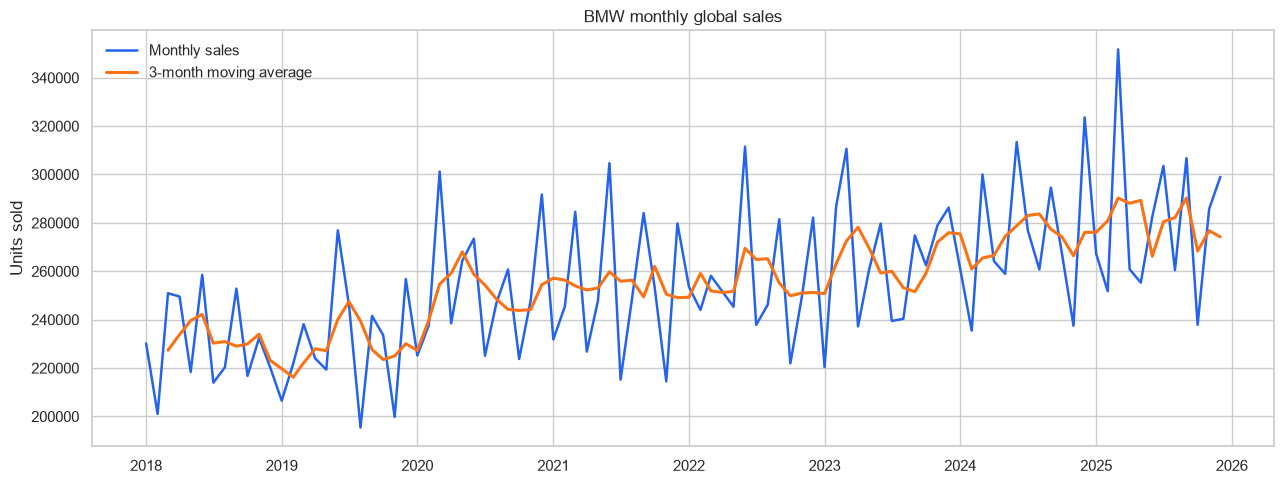

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly["Units_Sold"], color=BLUE, lw=1.8, label="Monthly sales")
ax.plot(monthly.index, monthly["Units_Sold"].rolling(3).mean(), color=ORANGE, lw=2.2, label="3-month moving average")
ax.set(title="BMW monthly global sales", ylabel="Units sold")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_monthly_sales.png", dpi=160, bbox_inches="tight")
plt.show()

In [14]:
yearly = raw.groupby("Year").agg(Units_Sold=("Units_Sold", "sum"), Revenue_EUR=("Revenue_EUR", "sum"))
yearly["Units_YoY"] = yearly["Units_Sold"].pct_change()
yearly["Revenue_YoY"] = yearly["Revenue_EUR"].pct_change()
display(yearly.round({"Units_YoY":4, "Revenue_YoY":4}))

,Units_Sold,Revenue_EUR,Units_YoY,Revenue_YoY
Year,,,,
2018,2765193,176775218399,NaN,NaN
2019,2759838,176552428685,-0.002,-0.001
2020,3036556,195638067880,0.100,0.108
2021,3036564,194292936404,0.000,-0.007
2022,3083306,197101324263,0.015,0.015
2023,3177788,203582572723,0.031,0.033
2024,3293423,211471067850,0.036,0.039
2025,3362777,215605681914,0.021,0.020


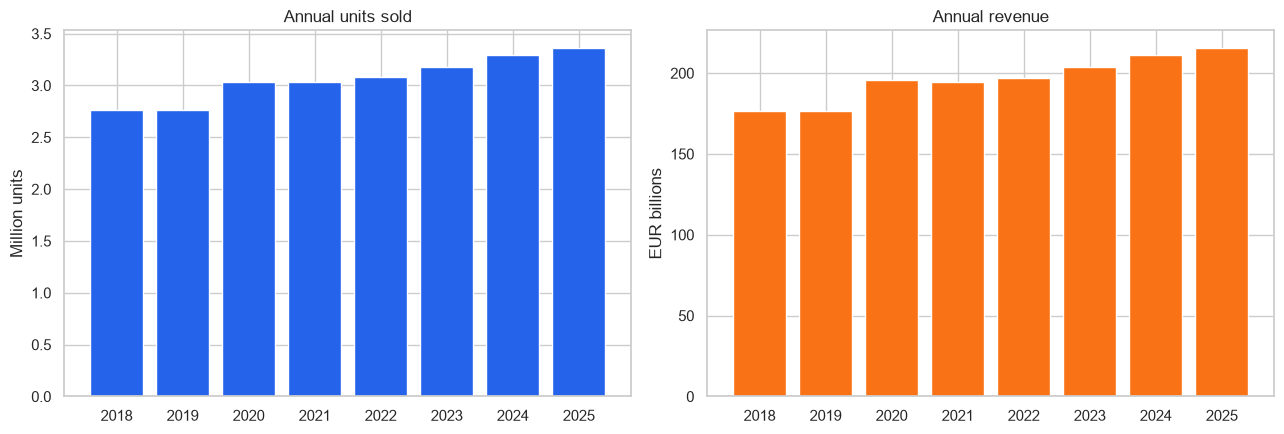

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(yearly.index.astype(str), yearly["Units_Sold"] / 1e6, color=BLUE)
axes[0].set(title="Annual units sold", ylabel="Million units")
axes[1].bar(yearly.index.astype(str), yearly["Revenue_EUR"] / 1e9, color=ORANGE)
axes[1].set(title="Annual revenue", ylabel="EUR billions")
plt.tight_layout(); plt.show()

In [16]:
region_summary = raw.groupby("Region").agg(
    Units_Sold=("Units_Sold", "sum"), Revenue_EUR=("Revenue_EUR", "sum"),
    Avg_Price_EUR=("Avg_Price_EUR", "mean"), BEV_Share=("BEV_Share", "mean")
).sort_values("Units_Sold", ascending=False)
region_summary["Units_Share"] = region_summary["Units_Sold"] / region_summary["Units_Sold"].sum()

model_summary = raw.groupby("Model").agg(
    Units_Sold=("Units_Sold", "sum"), Revenue_EUR=("Revenue_EUR", "sum"),
    Avg_Price_EUR=("Avg_Price_EUR", "mean"), BEV_Share=("BEV_Share", "mean")
).sort_values("Units_Sold", ascending=False)
model_summary["Units_Share"] = model_summary["Units_Sold"] / model_summary["Units_Sold"].sum()

display(region_summary)
display(model_summary)

,Units_Sold,Revenue_EUR,Avg_Price_EUR,BEV_Share,Units_Share
Region,,,,,
China,6256750,401755020483,"63,846.549",0.107,0.255
RestOfWorld,6113872,391071034606,"63,879.422",0.108,0.249
USA,6099647,389314290428,"63,882.948",0.108,0.249
Europe,6045176,388878952601,"63,809.327",0.108,0.247


,Units_Sold,Revenue_EUR,Avg_Price_EUR,BEV_Share,Units_Share
Model,,,,,
iX,3136912,235060013889,"74,965.344",0.107,0.128
i4,3125687,202904898753,"64,919.352",0.108,0.127
X7,3112074,286427856714,"92,006.490",0.108,0.127
X5,3085134,212814244305,"68,940.979",0.107,0.126
5 Series,3052524,188992092821,"61,935.234",0.108,0.125
X3,3025861,175547140738,"58,018.552",0.107,0.123
3 Series,3006048,144338948833,"47,986.495",0.107,0.123
MINI,2971205,124934102065,"42,064.047",0.107,0.121


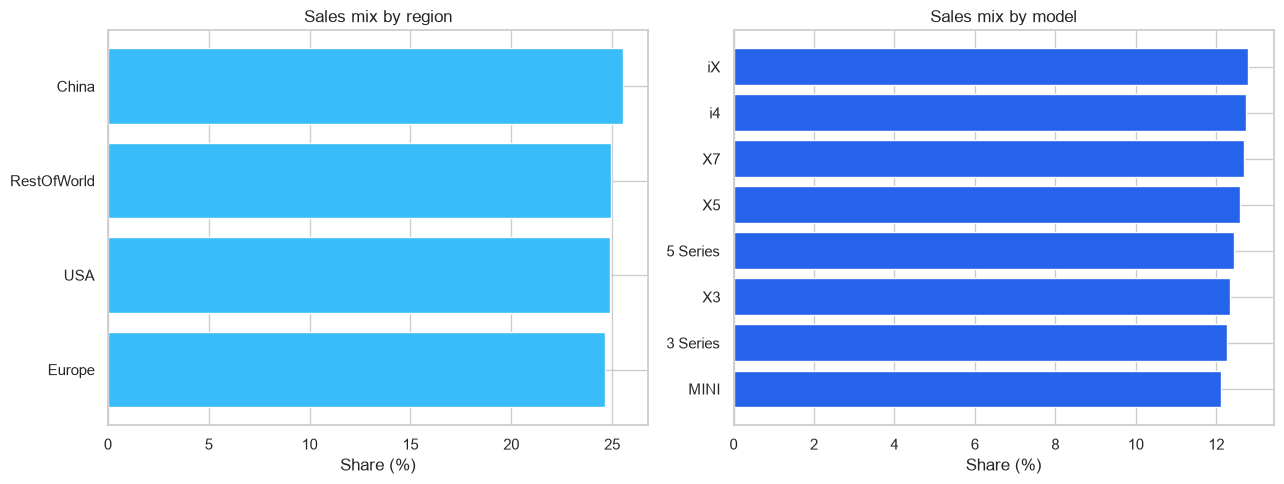

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rs = region_summary.sort_values("Units_Share")
ms = model_summary.sort_values("Units_Share")
axes[0].barh(rs.index, rs["Units_Share"] * 100, color="#38BDF8")
axes[0].set(title="Sales mix by region", xlabel="Share (%)")
axes[1].barh(ms.index, ms["Units_Share"] * 100, color=BLUE)
axes[1].set(title="Sales mix by model", xlabel="Share (%)")
plt.tight_layout(); plt.show()

### 판매 영향 요인 탐색

수준값 상관은 함께 증가하는 장기 추세에 의해 부풀려질 수 있다. 따라서 월별 수준의 Spearman 상관과 전년동월 변화율의 Spearman 상관을 함께 비교한다. 매출은 판매량×가격으로 정의되므로 판매량과의 높은 상관을 인과관계로 해석하지 않는다.

In [18]:
driver_cols = ["Revenue_EUR", "Avg_Price_EUR", "BEV_Share", "Premium_Share", "GDP_Growth", "Fuel_Price_Index"]
level_corr = monthly[["Units_Sold", *driver_cols]].corr(method="spearman")["Units_Sold"].drop("Units_Sold")
yoy_corr = monthly[["Units_Sold", *driver_cols]].pct_change(12).replace([np.inf, -np.inf], np.nan).corr(method="spearman")["Units_Sold"].drop("Units_Sold")
driver_correlation = pd.DataFrame({"Level": level_corr, "YoY_change": yoy_corr}).sort_values("YoY_change", key=lambda s: s.abs(), ascending=False)
display(driver_correlation)

,Level,YoY_change
Revenue_EUR,0.989,0.970
Avg_Price_EUR,0.158,0.237
GDP_Growth,-0.002,0.062
BEV_Share,0.541,-0.048
Premium_Share,-0.115,-0.044
Fuel_Price_Index,0.550,-0.003


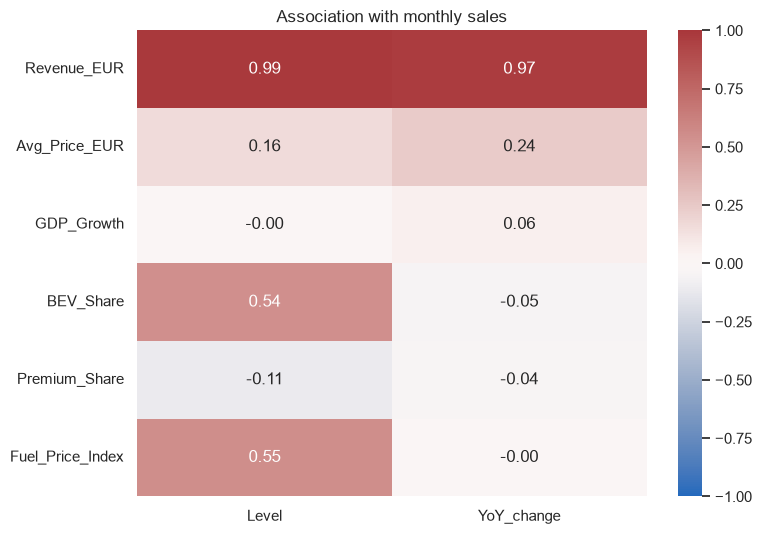

In [19]:
plt.figure(figsize=(8, 5.5))
sns.heatmap(driver_correlation, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Association with monthly sales")
plt.tight_layout(); plt.show()

**EDA 판단**

- 지역과 차종 비중이 비교적 균형적이어서 bottom-up 합산의 분산 효과를 기대할 수 있다.
- BEV 침투율과 유가 지수는 수준값에서 판매량과 함께 증가하지만 YoY 상관은 거의 사라진다. 공통 시간 추세의 영향으로 본다.
- 미래 GDP·유가·가격 값이 제공되지 않았으므로 외생변수로 억지 투입하지 않는다. 단변량 예측을 본선으로 두고, 외부 전망이 있을 때만 시나리오 분석으로 확장한다.

## 5. 시간 분할과 누수 방지

In [20]:
y = monthly["Units_Sold"].astype(float)
outer_train, test = y.iloc[:-12], y.iloc[-12:]
inner_train, inner_val = outer_train.iloc[:-12], outer_train.iloc[-12:]

split_info = pd.DataFrame([
    ["Inner train", inner_train.index.min(), inner_train.index.max(), len(inner_train), "모델 학습"],
    ["Inner validation", inner_val.index.min(), inner_val.index.max(), len(inner_val), "후보/파라미터 선택"],
    ["Outer train", outer_train.index.min(), outer_train.index.max(), len(outer_train), "선택 모델 재학습"],
    ["Final test", test.index.min(), test.index.max(), len(test), "최종 1회 평가"],
], columns=["Split", "Start", "End", "Months", "Purpose"])
display(split_info)

,Split,Start,End,Months,Purpose
0,Inner train,2018-01-01,2023-12-01,72,모델 학습
1,Inner validation,2024-01-01,2024-12-01,12,후보/파라미터 선택
2,Outer train,2018-01-01,2024-12-01,84,선택 모델 재학습
3,Final test,2025-01-01,2025-12-01,12,최종 1회 평가


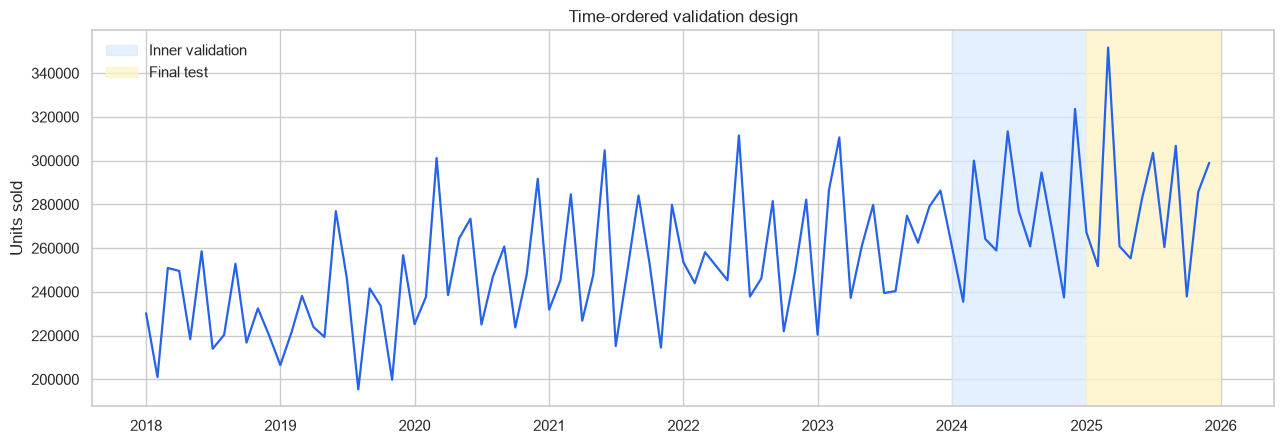

In [21]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(y.index, y, color=BLUE, lw=1.6)
ax.axvspan(inner_val.index.min(), inner_val.index.max()+pd.offsets.MonthEnd(1), color="#DBEAFE", alpha=.7, label="Inner validation")
ax.axvspan(test.index.min(), test.index.max()+pd.offsets.MonthEnd(1), color="#FEF3C7", alpha=.8, label="Final test")
ax.set(title="Time-ordered validation design", ylabel="Units sold")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 6. 주기 탐색: 3·6·12개월 후보

In [22]:
# 주기 탐색도 최종 테스트를 제외한 outer_train에서만 수행합니다.
t = np.arange(len(outer_train))
detrended = outer_train - np.polyval(np.polyfit(t, outer_train.to_numpy(), 1), t)
acf_values = acf(detrended, nlags=36, fft=False)
freqs, power = periodogram(detrended)

season_rows = []
for s in (3, 6, 12):
    nearest = int(np.argmin(np.abs(freqs - 1/s)))
    season_rows.append({"period": s, "acf": acf_values[s], "spectral_power": power[nearest]})

seasonality_table = pd.DataFrame(season_rows)
seasonality_table["acf_rank"] = seasonality_table["acf"].rank(ascending=False, method="min")
seasonality_table["power_rank"] = seasonality_table["spectral_power"].rank(ascending=False, method="min")
seasonality_table["rank_sum"] = seasonality_table["acf_rank"] + seasonality_table["power_rank"]
seasonality_table = seasonality_table.sort_values(["rank_sum", "period"]).reset_index(drop=True)
SELECTED_PERIOD = int(seasonality_table.iloc[0]["period"])
display(seasonality_table)
print("선택 주기:", SELECTED_PERIOD, "개월")

,period,acf,spectral_power,acf_rank,power_rank,rank_sum
0,3,0.595,"28,130,889,162.867",1.000,1.000,2.000
1,6,0.491,"258,904,597.798",2.000,3.000,5.000
2,12,0.409,"1,549,046,311.402",3.000,2.000,5.000


선택 주기: 3 개월


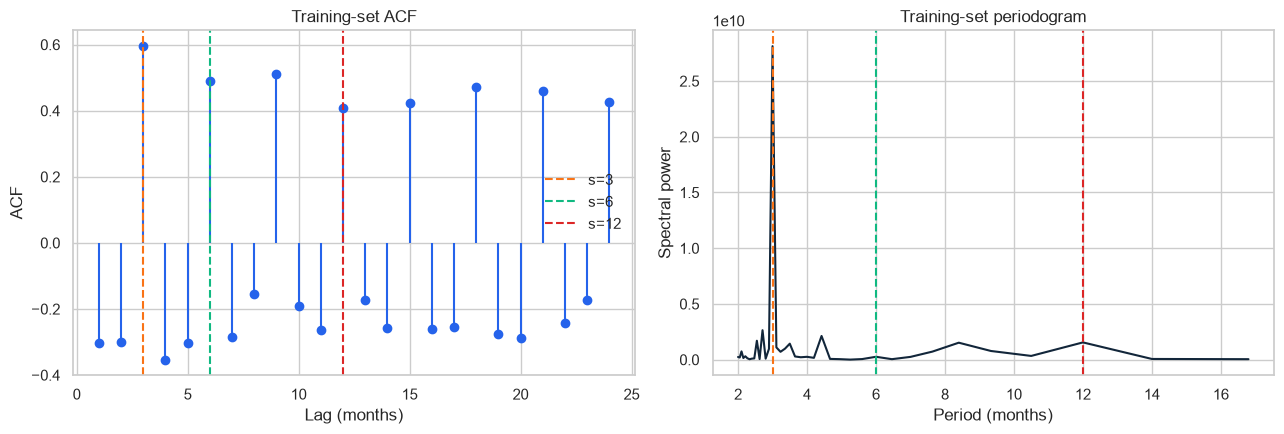

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].stem(range(1, 25), acf_values[1:25], linefmt=BLUE, markerfmt="o", basefmt=" ")
for s, c in [(3, ORANGE), (6, GREEN), (12, RED)]: axes[0].axvline(s, color=c, ls="--", label=f"s={s}")
axes[0].set(title="Training-set ACF", xlabel="Lag (months)", ylabel="ACF")
axes[0].legend(frameon=False)

period_df = pd.DataFrame({"Period": 1/freqs[1:], "Power": power[1:]}).replace([np.inf, -np.inf], np.nan).dropna()
view = period_df[(period_df["Period"] >= 2) & (period_df["Period"] <= 18)].sort_values("Period")
axes[1].plot(view["Period"], view["Power"], color=NAVY)
for s, c in [(3, ORANGE), (6, GREEN), (12, RED)]: axes[1].axvline(s, color=c, ls="--")
axes[1].set(title="Training-set periodogram", xlabel="Period (months)", ylabel="Spectral power")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_seasonality_evidence.png", dpi=160, bbox_inches="tight")
plt.show()

3개월 지연 ACF와 periodogram 파워가 모두 가장 높다. 월별 자료라도 연간 주기만 있는 것은 아니며, 이 데이터에서는 분기 말 판매 패턴이 지배적이다. 따라서 STL과 SARIMA의 기준 주기는 `s=3`으로 정한다. Holt-Winters는 예측 성능을 위해 `s=3, 6, 12`를 모두 검증한다.

## 7. Robust STL 분해와 잔차 검토

In [24]:
stl = STL(y, period=SELECTED_PERIOD, robust=True).fit()
stl_frame = pd.DataFrame({
    "Observed": y,
    "Trend": stl.trend,
    "Seasonal": stl.seasonal,
    "Residual": stl.resid,
})
display(stl_frame.head())

,Observed,Trend,Seasonal,Residual
Date,,,,
2018-01-01,"230,195.000","226,389.541",501.542,"3,303.916"
2018-02-01,"201,033.000","227,494.394","-23,674.359","-2,787.035"
2018-03-01,"250,912.000","228,898.601","24,617.629","-2,604.230"
2018-04-01,"249,552.000","230,540.172","-5,031.213","24,043.040"
2018-05-01,"218,362.000","232,712.950","-16,662.655","2,311.705"


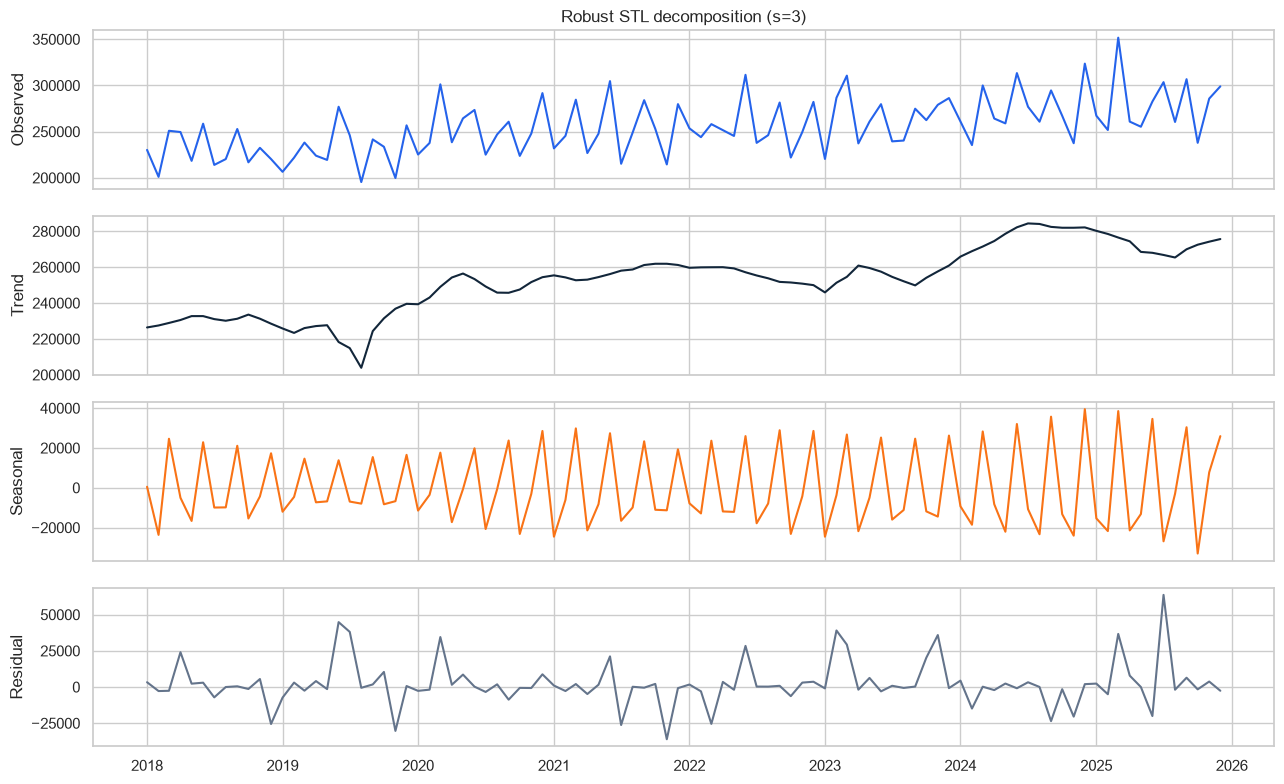

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
for ax, col, color in zip(axes, stl_frame.columns, [BLUE, NAVY, ORANGE, GRAY]):
    ax.plot(stl_frame.index, stl_frame[col], color=color, lw=1.5)
    ax.set_ylabel(col)
axes[0].set_title(f"Robust STL decomposition (s={SELECTED_PERIOD})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_stl.png", dpi=160, bbox_inches="tight")
plt.show()

In [26]:
resid = stl_frame["Residual"]
median = resid.median()
mad = np.median(np.abs(resid - median))
robust_z = 0.6745 * (resid - median) / max(mad, 1e-9)
residual_review = pd.DataFrame({"Units_Sold": y, "Residual": resid, "Robust_Z": robust_z})
residual_review["Review_Flag"] = residual_review["Robust_Z"].abs() > 3.5
display(residual_review[residual_review["Review_Flag"]].sort_values("Robust_Z", key=lambda s: s.abs(), ascending=False).head(15))
print("검토 플래그 월:", residual_review["Review_Flag"].sum())

,Units_Sold,Residual,Robust_Z,Review_Flag
Date,,,,
2025-07-01,"303,552.000","63,648.942",14.951,True
2019-06-01,"276,921.000","44,831.101",10.512,True
2023-02-01,"286,648.000","39,061.902",9.151,True
2019-07-01,"246,019.000","38,077.179",8.919,True
2025-03-01,"351,705.000","36,680.975",8.590,True
2021-11-01,"214,477.000","-36,085.171",-8.574,True
2023-11-01,"279,023.000","35,893.669",8.404,True
2020-03-01,"301,212.000","34,516.712",8.079,True
2019-11-01,"199,779.000","-30,319.705",-7.214,True


검토 플래그 월: 21


플래그는 **삭제 대상이 아니라 검토 대상**이다. 재구성 데이터에서 입력 오류라는 증거가 없고, 분기 월 급증이 사업 패턴일 수 있으므로 원값을 유지한다. 임의 대체는 실제 피크 예측력을 약화시킬 수 있다.

In [27]:
stationarity = pd.DataFrame({
    "Series": ["Level", "First difference"],
    "ADF_p": [adfuller(outer_train)[1], adfuller(outer_train.diff().dropna())[1]],
    "KPSS_p": [kpss(outer_train, regression="ct", nlags="auto")[1], kpss(outer_train.diff().dropna(), regression="c", nlags="auto")[1]],
})
display(stationarity)

,Series,ADF_p,KPSS_p
0,Level,0.940,0.100
1,First difference,0.001,0.100


## 8. 평가 함수와 기준선

In [28]:
def score(actual, pred):
    a = np.asarray(actual, dtype=float)
    p = np.asarray(pred, dtype=float)
    return {
        "MAE": mean_absolute_error(a, p),
        "RMSE": np.sqrt(mean_squared_error(a, p)),
        "sMAPE": np.mean(2*np.abs(a-p)/np.maximum(np.abs(a)+np.abs(p), 1e-9))*100,
        "WAPE": np.sum(np.abs(a-p))/np.maximum(np.sum(np.abs(a)), 1e-9)*100,
        "Bias": np.mean(p-a),
    }

def seasonal_naive(train, horizon, period):
    idx = pd.date_range(train.index[-1] + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
    return pd.Series(np.resize(train.iloc[-period:].to_numpy(), horizon), index=idx)

In [29]:
baseline_preds = {
    "Naive": pd.Series(np.repeat(inner_train.iloc[-1], len(inner_val)), index=inner_val.index),
    f"Seasonal naive (s={SELECTED_PERIOD})": seasonal_naive(inner_train, len(inner_val), SELECTED_PERIOD).set_axis(inner_val.index),
    "Seasonal naive (s=12)": seasonal_naive(inner_train, len(inner_val), 12).set_axis(inner_val.index),
}
baseline_validation = pd.DataFrame([
    {"Family":"Baseline", "Model":name, **score(inner_val, pred)} for name, pred in baseline_preds.items()
]).sort_values("MAE")
display(baseline_validation)

,Family,Model,MAE,RMSE,sMAPE,WAPE,Bias
1,Baseline,Seasonal naive (s=3),"19,354.917","24,119.202",7.036,7.052,"1,477.417"
0,Baseline,Naive,"26,255.250","29,365.090",9.491,9.566,"11,871.083"
2,Baseline,Seasonal naive (s=12),"27,182.083","31,087.986",10.209,9.904,"-9,636.250"


## 9. 지수평활 모델 개선

In [30]:
def fit_hw(train, horizon, period, seasonal, damped):
    fit = ExponentialSmoothing(
        train, trend="add", damped_trend=damped,
        seasonal=seasonal, seasonal_periods=period,
        initialization_method="estimated"
    ).fit(optimized=True, use_brute=True)
    return pd.Series(fit.forecast(horizon)), fit

exp_rows = []

ses = SimpleExpSmoothing(inner_train, initialization_method="estimated").fit(optimized=True)
exp_rows.append({"Family":"Exponential smoothing", "Model":"SES", **score(inner_val, ses.forecast(len(inner_val)))})

for damped in (False, True):
    fit = Holt(inner_train, damped_trend=damped, initialization_method="estimated").fit(optimized=True)
    exp_rows.append({"Family":"Exponential smoothing", "Model":f"Holt damped={damped}", **score(inner_val, fit.forecast(len(inner_val)))})

for period in (3, 6, 12):
    for seasonal in ("add", "mul"):
        for damped in (False, True):
            try:
                pred, _ = fit_hw(inner_train, len(inner_val), period, seasonal, damped)
                exp_rows.append({
                    "Family":"Exponential smoothing",
                    "Model":f"HW s={period}, seasonal={seasonal}, damped={damped}",
                    **score(inner_val, pred)
                })
            except Exception:
                pass

exp_validation = pd.DataFrame(exp_rows).sort_values("MAE").reset_index(drop=True)
BEST_EXP_NAME = exp_validation.iloc[0]["Model"]
display(exp_validation.head(12))
print("선택:", BEST_EXP_NAME)

,Family,Model,MAE,RMSE,sMAPE,WAPE,Bias
0,Exponential smoothing,"HW s=12, seasonal=add, damped=False","11,644.111","14,913.961",4.320,4.243,"-2,890.692"
1,Exponential smoothing,"HW s=12, seasonal=mul, damped=False","12,276.639","16,016.029",4.617,4.473,"-2,481.742"
2,Exponential smoothing,"HW s=12, seasonal=add, damped=True","12,627.321","15,723.290",4.681,4.601,"-5,374.764"
3,Exponential smoothing,"HW s=6, seasonal=mul, damped=False","12,866.765","15,641.320",4.802,4.688,"-5,500.348"
4,Exponential smoothing,"HW s=6, seasonal=add, damped=False","13,225.326","16,128.160",4.881,4.819,"-5,846.747"
5,Exponential smoothing,"HW s=12, seasonal=mul, damped=True","13,474.419","16,761.461",5.049,4.910,"-5,089.240"
6,Exponential smoothing,"HW s=3, seasonal=mul, damped=False","13,515.066","15,977.913",5.018,4.924,"-5,928.432"
7,Exponential smoothing,"HW s=3, seasonal=mul, damped=True","14,600.148","17,010.786",5.426,5.320,"-8,246.552"
8,Exponential smoothing,"HW s=3, seasonal=add, damped=False","14,938.334","17,710.011",5.558,5.443,"-5,213.936"
9,Exponential smoothing,"HW s=6, seasonal=mul, damped=True","15,172.126","17,249.896",5.642,5.528,"-9,091.034"


선택: HW s=12, seasonal=add, damped=False


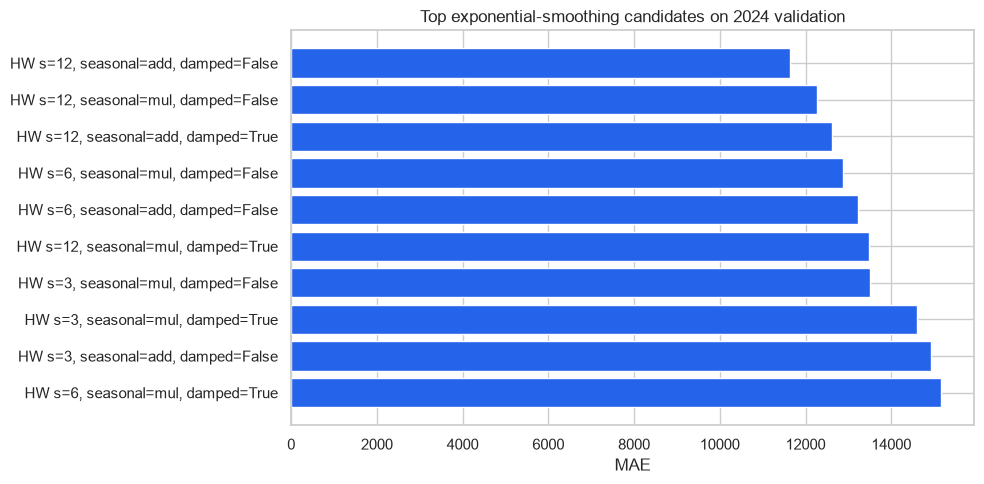

In [31]:
plt.figure(figsize=(10, 5))
top = exp_validation.head(10).sort_values("MAE")
plt.barh(top["Model"], top["MAE"], color=BLUE)
plt.gca().invert_yaxis()
plt.title("Top exponential-smoothing candidates on 2024 validation")
plt.xlabel("MAE")
plt.tight_layout(); plt.show()

## 10. ARIMA 그리드 탐색

In [32]:
arima_rows = []
for p in range(4):
    for d in range(3):
        for q in range(4):
            try:
                fit = ARIMA(inner_train, order=(p,d,q)).fit()
                pred = pd.Series(fit.forecast(len(inner_val)), index=inner_val.index)
                arima_rows.append({"order":(p,d,q), "AIC":fit.aic, **score(inner_val, pred)})
            except Exception:
                pass

arima_validation = pd.DataFrame(arima_rows).sort_values(["MAE", "AIC"]).reset_index(drop=True)
BEST_ARIMA_ORDER = tuple(arima_validation.iloc[0]["order"])
display(arima_validation.head(12))
print("선택:", BEST_ARIMA_ORDER)

,order,AIC,MAE,RMSE,sMAPE,WAPE,Bias
0,"(3, 1, 3)","1,696.735","20,364.518","25,378.009",7.375,7.420,"-2,134.054"
1,"(2, 1, 2)","1,681.535","21,733.208","25,827.302",7.883,7.919,"3,814.393"
2,"(1, 1, 2)","1,677.737","21,788.105","27,411.598",7.892,7.939,"-5,511.915"
3,"(1, 1, 1)","1,679.502","21,844.772","27,354.788",7.913,7.959,"-5,185.834"
4,"(0, 1, 1)","1,679.110","21,878.398","27,316.963",7.926,7.972,"-4,983.027"
5,"(0, 1, 2)","1,681.049","21,879.876","27,310.440",7.927,7.972,"-4,956.659"
6,"(2, 1, 0)","1,693.023","22,887.949","26,650.311",8.298,8.340,"4,111.299"
7,"(3, 0, 0)","1,639.413","23,061.775","29,596.326",8.397,8.403,"-13,633.289"
8,"(2, 1, 1)","1,687.102","23,308.641","27,125.594",8.447,8.493,"4,736.308"
9,"(3, 0, 3)","1,634.672","24,029.267","26,708.900",8.979,8.755,"-12,762.240"


선택: (3, 1, 3)


AIC는 참고값으로만 사용한다. 최종 순위는 미래 구간인 2024년 MAE가 우선이다. AIC가 낮아도 검증 MAE가 높으면 채택하지 않는다.

## 11. SARIMA 그리드 탐색

In [33]:
sarima_rows = []
for p in range(3):
    for d in (0,1):
        for q in range(3):
            for P in range(2):
                for D in (0,1):
                    for Q in range(2):
                        if p+d+q+P+D+Q == 0:
                            continue
                        order = (p,d,q)
                        seasonal_order = (P,D,Q,SELECTED_PERIOD)
                        try:
                            fit = SARIMAX(
                                inner_train, order=order, seasonal_order=seasonal_order,
                                enforce_stationarity=False, enforce_invertibility=False
                            ).fit(disp=False, maxiter=250)
                            pred = pd.Series(fit.forecast(len(inner_val)), index=inner_val.index)
                            sarima_rows.append({"order":order, "seasonal_order":seasonal_order, "AIC":fit.aic, **score(inner_val, pred)})
                        except Exception:
                            pass

sarima_validation = pd.DataFrame(sarima_rows).sort_values(["MAE", "AIC"]).reset_index(drop=True)
BEST_SARIMA_ORDER = tuple(sarima_validation.iloc[0]["order"])
BEST_SARIMA_SEASONAL = tuple(sarima_validation.iloc[0]["seasonal_order"])
display(sarima_validation.head(12))
print("선택:", BEST_SARIMA_ORDER, "x", BEST_SARIMA_SEASONAL)

,order,seasonal_order,AIC,MAE,RMSE,sMAPE,WAPE,Bias
0,"(0, 1, 0)","(0, 1, 1, 3)","1,487.804","16,462.605","21,565.973",6.030,5.998,"5,014.374"
1,"(0, 1, 0)","(1, 1, 1, 3)","1,488.678","16,715.645","22,350.055",6.120,6.091,"6,911.920"
2,"(2, 1, 2)","(0, 1, 1, 3)","1,429.354","17,512.743","24,098.578",6.409,6.381,"12,039.849"
3,"(1, 1, 2)","(0, 1, 1, 3)","1,427.784","17,554.918","24,108.584",6.422,6.396,"11,959.702"
4,"(1, 0, 2)","(1, 0, 1, 3)","1,534.319","17,634.790","21,265.687",6.455,6.425,-330.289
5,"(0, 0, 2)","(1, 0, 1, 3)","1,773.207","17,763.038","21,464.438",6.508,6.472,241.322
6,"(1, 0, 1)","(1, 0, 1, 3)","1,535.844","17,867.064","22,943.788",6.500,6.510,"2,495.123"
7,"(2, 0, 2)","(1, 0, 1, 3)","1,527.075","17,951.184","21,281.209",6.578,6.541,"-1,136.972"
8,"(2, 0, 0)","(1, 0, 1, 3)","1,556.029","17,963.457","22,991.932",6.536,6.545,"2,335.282"
9,"(0, 0, 1)","(1, 0, 1, 3)","1,797.359","17,968.825","22,990.364",6.538,6.547,"2,315.852"


선택: (0, 1, 0) x (0, 1, 1, 3)


## 12. Prophet: 기본 모델에서 튜닝 모델로

In [34]:
def prophet_forecast(train, horizon, config):
    frame = train.rename("y").reset_index().rename(columns={train.index.name or "index":"ds"})
    model = Prophet(
        yearly_seasonality=config.get("yearly", "auto"),
        weekly_seasonality=False, daily_seasonality=False,
        changepoint_prior_scale=config.get("cps", 0.05),
        seasonality_prior_scale=config.get("sps", 10.0),
        seasonality_mode=config.get("mode", "additive"),
        interval_width=0.95,
    )
    if config.get("quarterly", False):
        model.add_seasonality(
            name="quarterly", period=365.25/4,
            fourier_order=config.get("fourier",3),
            prior_scale=config.get("sps",10.0)
        )
    model.fit(frame)
    dates = pd.date_range(train.index[-1]+pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
    fc = model.predict(pd.DataFrame({"ds":dates})).set_index("ds")
    return fc[["yhat","yhat_lower","yhat_upper"]], model

In [35]:
prophet_configs = [{
    "name":"Prophet basic", "quarterly":False,
    "cps":0.05, "sps":10.0, "mode":"additive", "yearly":"auto"
}]
for cps in (0.01, 0.05, 0.2, 0.5):
    for sps in (1.0, 10.0):
        for mode in ("additive", "multiplicative"):
            prophet_configs.append({
                "name":f"Prophet tuned cps={cps}, sps={sps}, mode={mode}",
                "quarterly":True, "fourier":3, "cps":cps, "sps":sps,
                "mode":mode, "yearly":True
            })

prophet_rows = []
for cfg in prophet_configs:
    try:
        fc, _ = prophet_forecast(inner_train, len(inner_val), cfg)
        pred = pd.Series(fc["yhat"].to_numpy(), index=inner_val.index)
        prophet_rows.append({"config":cfg["name"], "config_object":cfg, **score(inner_val, pred)})
    except Exception as exc:
        print("Prophet failed:", cfg["name"], exc)

prophet_validation = pd.DataFrame(prophet_rows).sort_values("MAE").reset_index(drop=True)
BEST_PROPHET_CONFIG = prophet_validation.iloc[0]["config_object"]
display(prophet_validation.drop(columns="config_object").head(12))
print("선택:", BEST_PROPHET_CONFIG["name"])

13:36:11 - cmdstanpy - INFO - Chain [1] start processing


13:36:11 - cmdstanpy - INFO - Chain [1] done processing


13:36:11 - cmdstanpy - INFO - Chain [1] start processing


13:36:11 - cmdstanpy - INFO - Chain [1] done processing


13:36:11 - cmdstanpy - INFO - Chain [1] start processing


...

13:36:17 - cmdstanpy - INFO - Chain [1] done processing


13:36:17 - cmdstanpy - INFO - Chain [1] start processing


13:36:18 - cmdstanpy - INFO - Chain [1] done processing


,config,MAE,RMSE,sMAPE,WAPE,Bias
0,Prophet basic,"17,040.164","21,110.441",6.410,6.209,"1,308.078"
1,"Prophet tuned cps=0.01, sps=1.0, mode=additive","17,701.297","20,809.624",6.591,6.450,"6,791.478"
2,"Prophet tuned cps=0.05, sps=1.0, mode=additive","17,705.591","20,813.065",6.593,6.451,"6,794.684"
3,"Prophet tuned cps=0.01, sps=10.0, mode=additive","17,929.395","21,053.262",6.674,6.533,"6,905.798"
4,"Prophet tuned cps=0.05, sps=10.0, mode=additive","17,932.713","21,054.877",6.675,6.534,"6,917.662"
5,"Prophet tuned cps=0.05, sps=1.0, mode=multipli...","19,038.220","22,133.605",7.073,6.937,"7,683.942"
6,"Prophet tuned cps=0.01, sps=1.0, mode=multipli...","19,214.522","22,229.007",7.130,7.001,"7,900.213"
7,"Prophet tuned cps=0.01, sps=10.0, mode=multipl...","19,274.638","22,426.200",7.161,7.023,"7,736.645"
8,"Prophet tuned cps=0.05, sps=10.0, mode=multipl...","19,358.720","22,443.924",7.186,7.054,"7,810.529"
9,"Prophet tuned cps=0.2, sps=1.0, mode=additive","20,132.927","24,173.934",7.360,7.336,"14,293.258"


선택: Prophet basic


## 13. 내부 검증 요약

In [36]:
inner_summary = pd.DataFrame([
    ["Baseline", baseline_validation.iloc[0]["Model"], baseline_validation.iloc[0]["MAE"]],
    ["Exponential smoothing", BEST_EXP_NAME, exp_validation.iloc[0]["MAE"]],
    ["ARIMA", str(BEST_ARIMA_ORDER), arima_validation.iloc[0]["MAE"]],
    ["SARIMA", f"{BEST_SARIMA_ORDER}x{BEST_SARIMA_SEASONAL}", sarima_validation.iloc[0]["MAE"]],
    ["Prophet", BEST_PROPHET_CONFIG["name"], prophet_validation.iloc[0]["MAE"]],
], columns=["Family", "Selected_candidate", "Validation_MAE"]).sort_values("Validation_MAE")
display(inner_summary)

,Family,Selected_candidate,Validation_MAE
1,Exponential smoothing,"HW s=12, seasonal=add, damped=False","11,644.111"
3,SARIMA,"(0, 1, 0)x(0, 1, 1, 3)","16,462.605"
4,Prophet,Prophet basic,"17,040.164"
0,Baseline,Seasonal naive (s=3),"19,354.917"
2,ARIMA,"(3, 1, 3)","20,364.518"


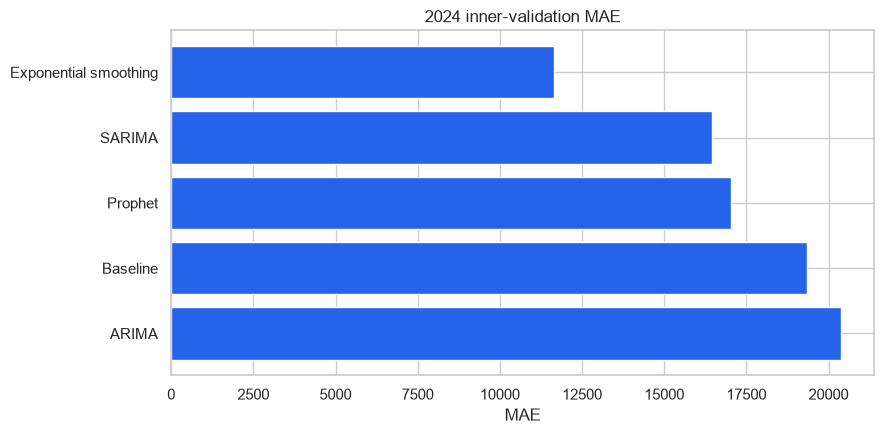

In [37]:
plt.figure(figsize=(9, 4.5))
plt.barh(inner_summary["Family"], inner_summary["Validation_MAE"], color=BLUE)
plt.gca().invert_yaxis()
plt.title("2024 inner-validation MAE")
plt.xlabel("MAE")
plt.tight_layout(); plt.show()

## 14. 선택 후보를 outer train에 재학습하고 2025 최종 평가

In [38]:
test_predictions = {}
final_rows = []

def add_final(family, name, pred, tuning):
    pred = pd.Series(np.asarray(pred), index=test.index)
    test_predictions[name] = pred
    final_rows.append({"Family":family, "Model":name, "Tuning":tuning, **score(test, pred)})

add_final("Baseline", "Naive", np.repeat(outer_train.iloc[-1], len(test)), "No tuning")
for period in (SELECTED_PERIOD, 12):
    add_final("Baseline", f"Seasonal naive (s={period})", seasonal_naive(outer_train, len(test), period), "No tuning")

In [39]:
if BEST_EXP_NAME == "SES":
    exp_fit = SimpleExpSmoothing(outer_train, initialization_method="estimated").fit(optimized=True)
    exp_pred = exp_fit.forecast(len(test))
elif BEST_EXP_NAME.startswith("Holt damped"):
    exp_fit = Holt(outer_train, damped_trend=BEST_EXP_NAME.endswith("True"), initialization_method="estimated").fit(optimized=True)
    exp_pred = exp_fit.forecast(len(test))
else:
    parts = {x.split("=")[0].strip():x.split("=")[1].strip() for x in BEST_EXP_NAME.replace("HW ","").split(",")}
    exp_pred, exp_fit = fit_hw(outer_train, len(test), int(parts["s"]), parts["seasonal"], parts["damped"]=="True")
add_final("Exponential smoothing", BEST_EXP_NAME, exp_pred, "Lowest 2024 validation MAE")

In [40]:
arima_fit = ARIMA(outer_train, order=BEST_ARIMA_ORDER).fit()
arima_pred = arima_fit.forecast(len(test))
ARIMA_NAME = f"ARIMA{BEST_ARIMA_ORDER}"
add_final("ARIMA", ARIMA_NAME, arima_pred, "Grid search on 2024")

sarima_fit = SARIMAX(
    outer_train, order=BEST_SARIMA_ORDER, seasonal_order=BEST_SARIMA_SEASONAL,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False, maxiter=400)
sarima_pred = sarima_fit.forecast(len(test))
SARIMA_NAME = f"SARIMA{BEST_SARIMA_ORDER}x{BEST_SARIMA_SEASONAL}"
add_final("SARIMA", SARIMA_NAME, sarima_pred, "Grid search on 2024")

prophet_fc, prophet_fit = prophet_forecast(outer_train, len(test), BEST_PROPHET_CONFIG)
PROPHET_NAME = BEST_PROPHET_CONFIG["name"]
add_final("Prophet", PROPHET_NAME, prophet_fc["yhat"], "Priors and quarterly seasonality tested on 2024")

13:36:18 - cmdstanpy - INFO - Chain [1] start processing


13:36:19 - cmdstanpy - INFO - Chain [1] done processing


In [41]:
final_comparison = pd.DataFrame(final_rows).sort_values("MAE").reset_index(drop=True)
BEST_DIRECT_MODEL = final_comparison.iloc[0]["Model"]
BEST_DIRECT_FAMILY = final_comparison.iloc[0]["Family"]
display(final_comparison.round({c:2 for c in ["MAE","RMSE","sMAPE","WAPE","Bias"]}))
print("직접 총량 챔피언:", BEST_DIRECT_MODEL)

,Family,Model,Tuning,MAE,RMSE,sMAPE,WAPE,Bias
0,ARIMA,"ARIMA(3, 1, 3)",Grid search on 2024,"17,761.870","22,574.160",6.270,6.340,-893.130
1,Prophet,Prophet basic,Priors and quarterly seasonality tested on 2024,"20,198.330","23,958.360",7.100,7.210,170.090
2,Exponential smoothing,"HW s=12, seasonal=add, damped=False",Lowest 2024 validation MAE,"21,015.110","26,273.070",7.380,7.500,-833.520
3,Baseline,Seasonal naive (s=12),No tuning,"21,113.170","26,782.900",7.440,7.530,"-5,779.500"
4,Baseline,Seasonal naive (s=3),No tuning,"23,845.580","27,342.810",8.560,8.510,"-4,138.080"
5,SARIMA,"SARIMA(0, 1, 0)x(0, 1, 1, 3)",Grid search on 2024,"44,307.190","51,564.030",14.630,15.810,"42,025.090"
6,Baseline,Naive,No tuning,"48,075.250","52,840.780",16.270,17.160,"43,395.580"


직접 총량 챔피언: ARIMA(3, 1, 3)


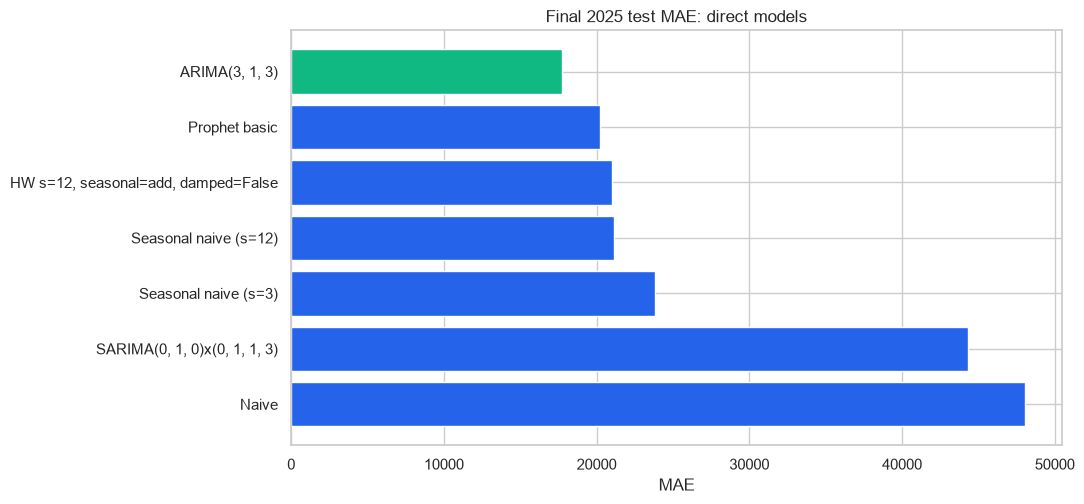

In [42]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ordered = final_comparison.sort_values("MAE")
colors = [GREEN if m == BEST_DIRECT_MODEL else BLUE for m in ordered["Model"]]
ax.barh(ordered["Model"], ordered["MAE"], color=colors)
ax.invert_yaxis(); ax.set(title="Final 2025 test MAE: direct models", xlabel="MAE")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_direct_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

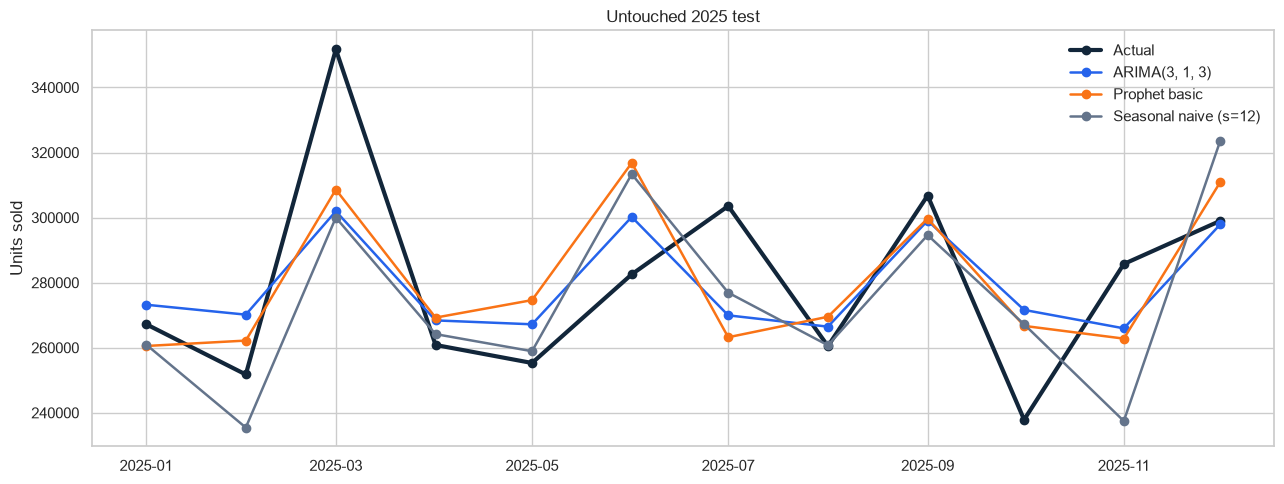

In [43]:
test_frame = pd.DataFrame({"Actual":test})
for name, pred in test_predictions.items(): test_frame[name] = pred

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_frame.index, test_frame["Actual"], color=NAVY, lw=3, marker="o", label="Actual")
for name, color in [(BEST_DIRECT_MODEL, BLUE), (PROPHET_NAME, ORANGE), ("Seasonal naive (s=12)", GRAY)]:
    ax.plot(test_frame.index, test_frame[name], lw=1.8, marker="o", label=name, color=color)
ax.set(title="Untouched 2025 test", ylabel="Units sold")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 15. 직접 챔피언 잔차 진단

In [44]:
selected_resid = pd.Series(arima_fit.resid).dropna()
lb = acorr_ljungbox(selected_resid, lags=[12], return_df=True)
diagnostics = pd.Series({
    "Ljung_Box_lag":12,
    "Ljung_Box_p":lb["lb_pvalue"].iloc[0],
    "Residual_mean":selected_resid.mean(),
    "Residual_std":selected_resid.std(ddof=1),
})
display(diagnostics.to_frame("value"))

,value
Ljung_Box_lag,12.000
Ljung_Box_p,0.472
Residual_mean,"8,845.351"
Residual_std,"36,493.148"


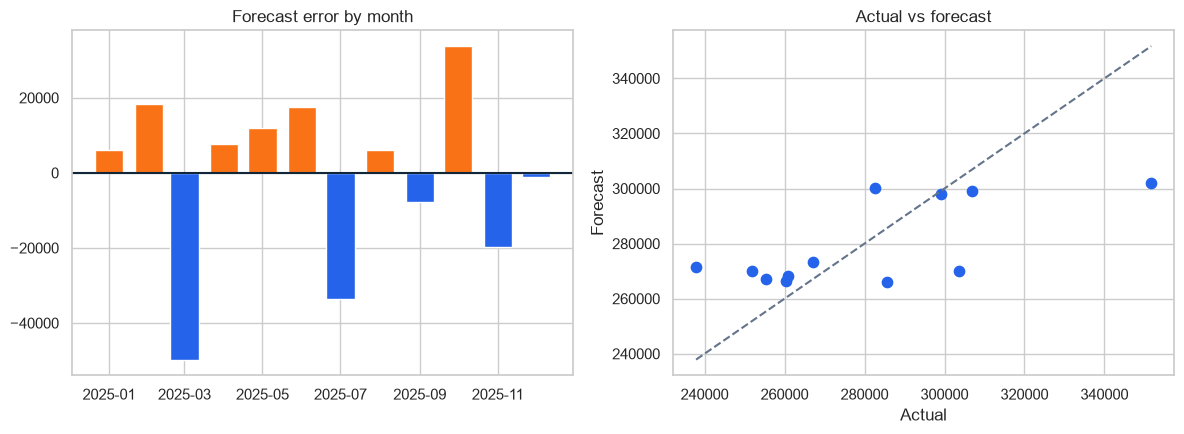

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
errors = test_frame[BEST_DIRECT_MODEL] - test_frame["Actual"]
axes[0].bar(errors.index, errors, width=22, color=np.where(errors>=0, ORANGE, BLUE))
axes[0].axhline(0, color=NAVY); axes[0].set_title("Forecast error by month")
axes[1].scatter(test_frame["Actual"], test_frame[BEST_DIRECT_MODEL], color=BLUE, s=55)
lo, hi = test_frame[["Actual",BEST_DIRECT_MODEL]].min().min(), test_frame[["Actual",BEST_DIRECT_MODEL]].max().max()
axes[1].plot([lo,hi],[lo,hi], ls="--", color=GRAY)
axes[1].set(title="Actual vs forecast", xlabel="Actual", ylabel="Forecast")
plt.tight_layout(); plt.show()

## 16. 심화: 지역·차종 bottom-up 예측

In [46]:
def choose_component_model(train, val, period):
    candidates = [(f"Seasonal naive (s={period})", seasonal_naive(train, len(val), period).set_axis(val.index), {"kind":"snaive"})]
    for seasonal in ("add","mul"):
        for damped in (False,True):
            try:
                pred, _ = fit_hw(train, len(val), period, seasonal, damped)
                pred.index = val.index
                candidates.append((f"HW {seasonal}, damped={damped}", pred, {"kind":"hw","seasonal":seasonal,"damped":damped}))
            except Exception:
                pass
    return min([(n, score(val,p)["MAE"], c) for n,p,c in candidates], key=lambda x:x[1])

def component_test_forecast(series, outer_train_len, horizon, period):
    train_all = series.iloc[:outer_train_len]
    train, val = train_all.iloc[:-horizon], train_all.iloc[-horizon:]
    method, _, cfg = choose_component_model(train, val, period)
    if cfg["kind"] == "snaive": pred = seasonal_naive(train_all, horizon, period)
    else: pred, _ = fit_hw(train_all, horizon, period, cfg["seasonal"], cfg["damped"])
    pred.index = series.index[outer_train_len:outer_train_len+horizon]
    return pred, method, cfg

def component_future_forecast(series, horizon, period, cfg):
    if cfg["kind"] == "snaive": return seasonal_naive(series, horizon, period)
    pred, _ = fit_hw(series, horizon, period, cfg["seasonal"], cfg["damped"])
    return pred

In [47]:
region_actual = raw.pivot_table(index="Date", columns="Region", values="Units_Sold", aggfunc="sum").asfreq("MS")
model_actual = raw.pivot_table(index="Date", columns="Model", values="Units_Sold", aggfunc="sum").asfreq("MS")

region_preds, region_cfgs, detail_rows = {}, {}, []
for col in region_actual:
    pred, method, cfg = component_test_forecast(region_actual[col].astype(float), len(outer_train), len(test), SELECTED_PERIOD)
    region_preds[col], region_cfgs[col] = pred, cfg
    detail_rows.append({"Level":"Region", "Segment":col, "Method":method, **score(region_actual[col].iloc[-12:], pred)})

region_bottom_up = pd.DataFrame(region_preds).sum(axis=1)
display(pd.DataFrame(detail_rows))

,Level,Segment,Method,MAE,RMSE,sMAPE,WAPE,Bias
0,Region,China,"HW add, damped=False","10,125.841","13,047.231",13.439,13.696,"-1,398.219"
1,Region,Europe,"HW mul, damped=False","7,355.681","9,337.231",10.548,10.701,831.416
2,Region,RestOfWorld,"HW add, damped=False","6,032.323","7,726.132",9.342,9.313,"2,040.544"
3,Region,USA,"HW add, damped=False","7,452.327","8,484.202",10.369,10.238,"-3,186.693"


In [48]:
model_preds, model_cfgs = {}, {}
for col in model_actual:
    pred, method, cfg = component_test_forecast(model_actual[col].astype(float), len(outer_train), len(test), SELECTED_PERIOD)
    model_preds[col], model_cfgs[col] = pred, cfg
    detail_rows.append({"Level":"Model", "Segment":col, "Method":method, **score(model_actual[col].iloc[-12:], pred)})

model_bottom_up = pd.DataFrame(model_preds).sum(axis=1)
hierarchy_detail = pd.DataFrame(detail_rows)
display(hierarchy_detail[hierarchy_detail["Level"]=="Model"])

,Level,Segment,Method,MAE,RMSE,sMAPE,WAPE,Bias
4,Model,3 Series,"HW mul, damped=True","6,627.008","8,764.117",19.163,18.773,"-3,160.019"
5,Model,5 Series,"HW mul, damped=True","5,990.079","7,988.698",16.548,16.644,"-2,461.118"
6,Model,MINI,"HW mul, damped=False","5,809.157","7,426.591",17.262,17.177,419.158
7,Model,X3,"HW mul, damped=True","7,036.333","8,394.958",21.424,21.788,-17.237
8,Model,X5,"HW add, damped=True","6,007.442","6,860.690",16.972,16.102,"-4,272.970"
9,Model,X7,"HW mul, damped=True","4,292.230","5,540.074",12.507,11.987,"-1,776.882"
10,Model,i4,"HW add, damped=False","7,316.455","8,876.244",22.137,22.441,"4,876.748"
11,Model,iX,"HW add, damped=False","5,274.889","6,581.240",14.571,14.215,-865.569


In [49]:
hierarchy_comparison = pd.DataFrame([
    {"Approach":"Direct total", "Model":BEST_DIRECT_MODEL, **score(test, test_predictions[BEST_DIRECT_MODEL])},
    {"Approach":"Region bottom-up", "Model":"Per-region validation-selected HW/seasonal naive", **score(test, region_bottom_up)},
    {"Approach":"Model bottom-up", "Model":"Per-model validation-selected HW/seasonal naive", **score(test, model_bottom_up)},
]).sort_values("MAE").reset_index(drop=True)

display(hierarchy_comparison)
BEST_APPROACH = hierarchy_comparison.iloc[0]["Approach"]
print("운영용 챔피언:", BEST_APPROACH)

,Approach,Model,MAE,RMSE,sMAPE,WAPE,Bias
0,Model bottom-up,Per-model validation-selected HW/seasonal naive,"16,436.856","23,076.152",5.773,5.865,"-7,257.889"
1,Region bottom-up,Per-region validation-selected HW/seasonal naive,"17,265.166","22,612.437",6.077,6.161,"-1,712.952"
2,Direct total,"ARIMA(3, 1, 3)","17,761.871","22,574.163",6.273,6.338,-893.132


운영용 챔피언: Model bottom-up


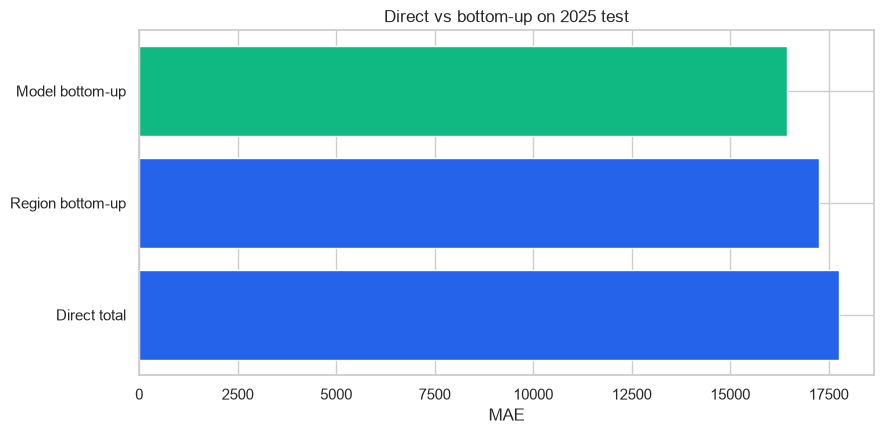

In [50]:
fig, ax = plt.subplots(figsize=(9, 4.5))
h = hierarchy_comparison.sort_values("MAE")
ax.barh(h["Approach"], h["MAE"], color=[GREEN if a==BEST_APPROACH else BLUE for a in h["Approach"]])
ax.invert_yaxis(); ax.set(title="Direct vs bottom-up on 2025 test", xlabel="MAE")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_hierarchy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

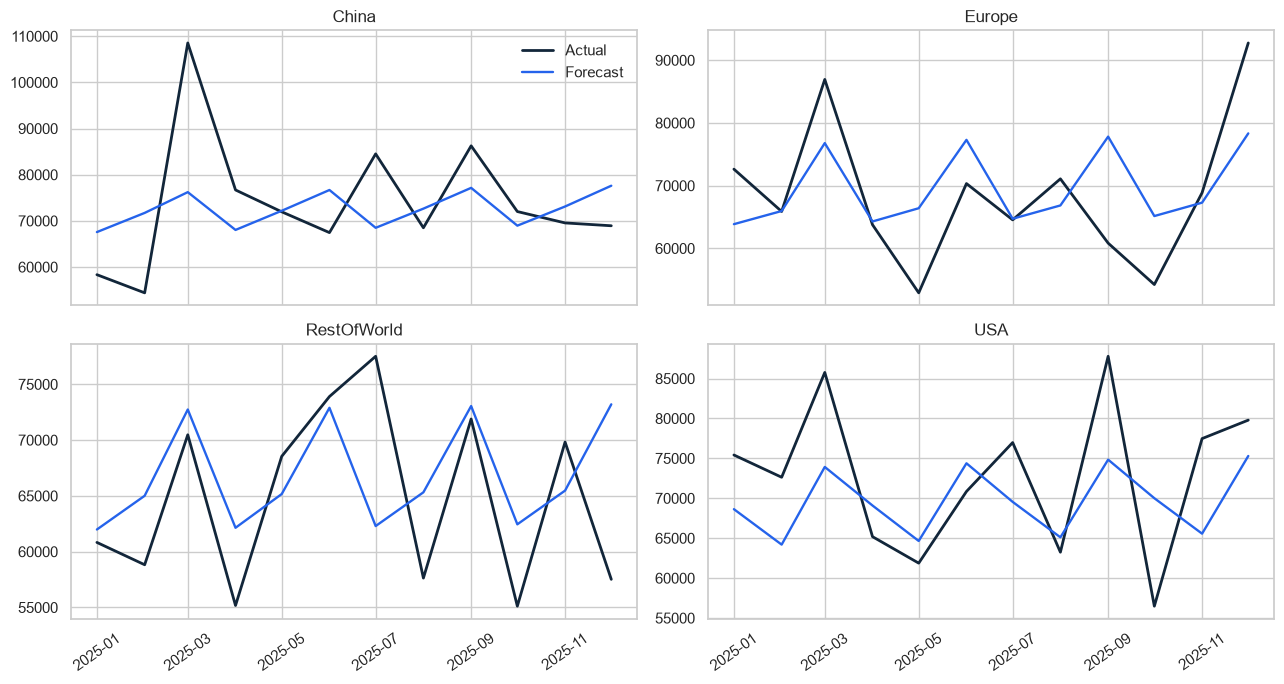

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, col in zip(axes.flat, region_actual.columns):
    actual = region_actual[col].iloc[-12:]
    ax.plot(actual.index, actual, color=NAVY, lw=2, label="Actual")
    ax.plot(region_preds[col].index, region_preds[col], color=BLUE, lw=1.7, label="Forecast")
    ax.set_title(col); ax.tick_params(axis="x", rotation=35)
axes[0,0].legend(frameon=False)
plt.tight_layout(); plt.show()

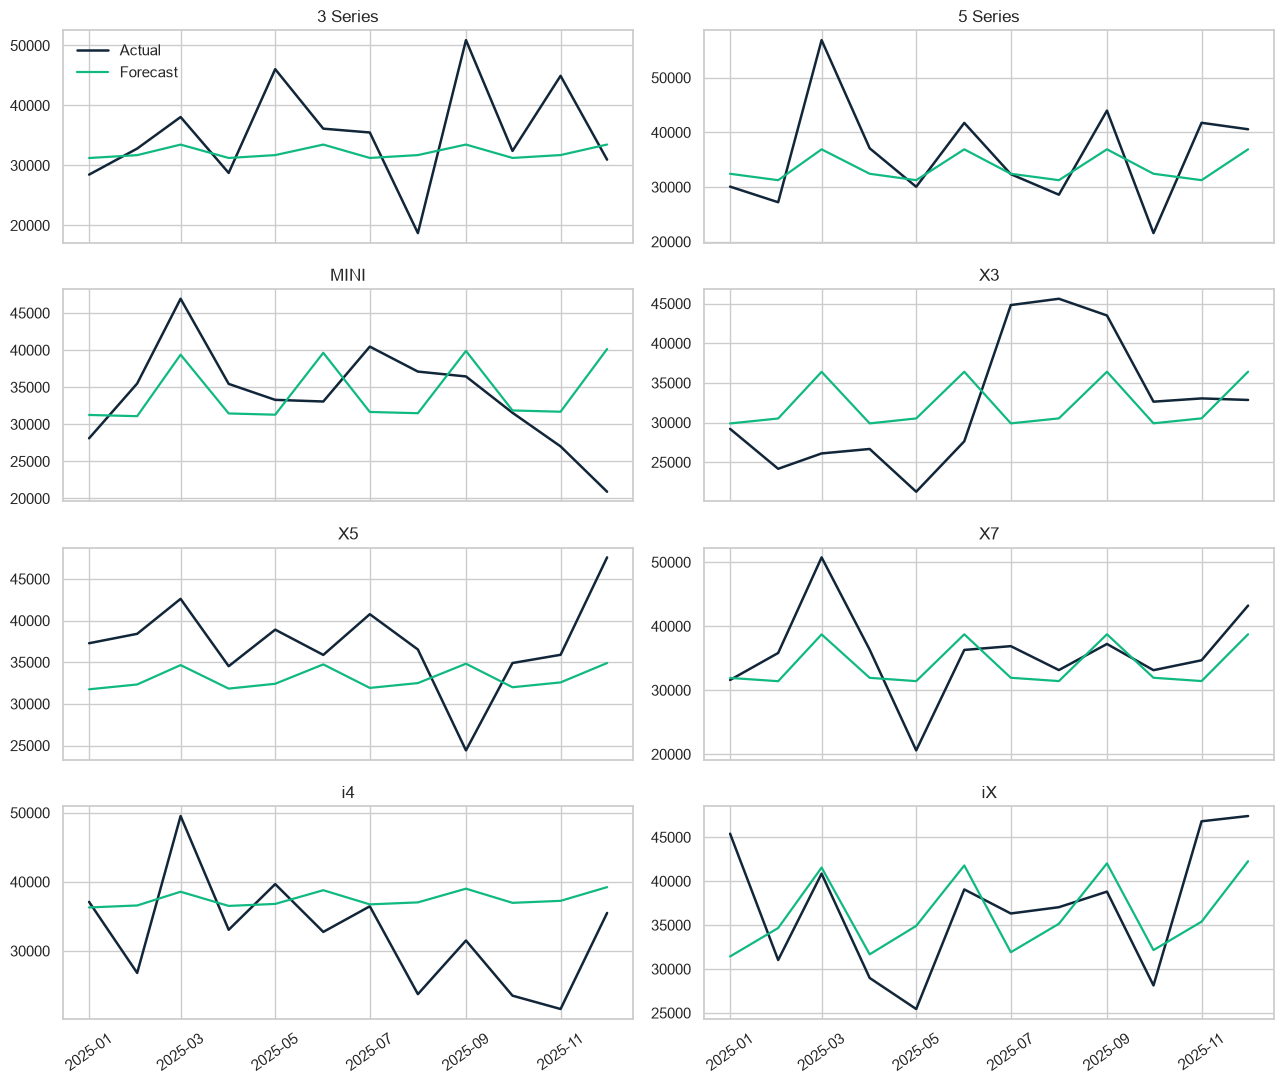

In [52]:
fig, axes = plt.subplots(4, 2, figsize=(13, 11), sharex=True)
for ax, col in zip(axes.flat, model_actual.columns):
    actual = model_actual[col].iloc[-12:]
    ax.plot(actual.index, actual, color=NAVY, lw=1.8, label="Actual")
    ax.plot(model_preds[col].index, model_preds[col], color=GREEN, lw=1.6, label="Forecast")
    ax.set_title(col); ax.tick_params(axis="x", rotation=35)
axes[0,0].legend(frameon=False)
plt.tight_layout(); plt.show()

차종별 bottom-up은 개별 차종의 오차가 모두 작아서가 아니라, 합산 시 과대·과소 오차가 일부 상쇄되어 총량 MAE가 낮아진 결과다. 총량 계획에는 유용하지만 개별 차종 의사결정에는 차종별 WAPE를 별도로 확인해야 한다.

## 17. 전체 데이터 재학습과 2026년 기준 예측

In [53]:
future_index = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq="MS")

# 직접 ARIMA 통제 예측과 모형 기반 구간
full_arima = ARIMA(y, order=BEST_ARIMA_ORDER).fit()
direct_fc = full_arima.get_forecast(12)
direct_point = pd.Series(direct_fc.predicted_mean.to_numpy(), index=future_index)
direct_ci = direct_fc.conf_int(alpha=0.05)
direct_lower = pd.Series(direct_ci.iloc[:,0].to_numpy(), index=future_index)
direct_upper = pd.Series(direct_ci.iloc[:,1].to_numpy(), index=future_index)

# 2024 내부 검증에서 선택한 차종별 구성을 유지하고 전체 데이터로 재학습
model_future = pd.DataFrame({
    col: component_future_forecast(model_actual[col].astype(float), 12, SELECTED_PERIOD, model_cfgs[col]).to_numpy()
    for col in model_actual.columns
}, index=future_index)
champion_point = model_future.sum(axis=1)

# 최종 홀드아웃 잔차 기반 근사 범위: 관측치가 12개이므로 참고용
champion_sigma = (test - model_bottom_up).std(ddof=1)
champion_lower = (champion_point - 1.96*champion_sigma).clip(lower=0)
champion_upper = champion_point + 1.96*champion_sigma

future_forecast = pd.DataFrame({
    "Forecast":champion_point,
    "Lower95_Approx":champion_lower,
    "Upper95_Approx":champion_upper,
    "Direct_ARIMA":direct_point,
    "Direct_Lower95":direct_lower,
    "Direct_Upper95":direct_upper,
})
display(future_forecast.round(0))

,Forecast,Lower95_Approx,Upper95_Approx,Direct_ARIMA,Direct_Lower95,Direct_Upper95
2026-01-01,"258,165.000","213,322.000","303,009.000","270,037.000","230,677.000","309,396.000"
2026-02-01,"260,409.000","215,566.000","305,252.000","265,965.000","224,988.000","306,941.000"
2026-03-01,"301,511.000","256,668.000","346,354.000","299,737.000","257,067.000","342,407.000"
2026-04-01,"258,850.000","214,007.000","303,693.000","272,028.000","228,296.000","315,760.000"
2026-05-01,"261,076.000","216,233.000","305,919.000","265,367.000","221,184.000","309,549.000"
2026-06-01,"302,222.000","257,379.000","347,065.000","298,705.000","253,219.000","344,190.000"
2026-07-01,"259,497.000","214,654.000","304,340.000","273,648.000","227,161.000","320,134.000"
2026-08-01,"261,712.000","216,869.000","306,555.000","264,851.000","217,938.000","311,764.000"
2026-09-01,"302,902.000","258,059.000","347,745.000","297,615.000","249,519.000","345,711.000"
2026-10-01,"260,121.000","215,278.000","304,964.000","275,182.000","226,110.000","324,255.000"


In [54]:
actual_2025 = test.sum()
forecast_2026 = future_forecast["Forecast"].sum()
print(f"2025 actual: {actual_2025:,.0f}")
print(f"2026 forecast: {forecast_2026:,.0f}")
print(f"YoY change: {forecast_2026/actual_2025-1:+.1%}")

2025 actual: 3,362,777
2026 forecast: 3,292,356
YoY change: -2.1%


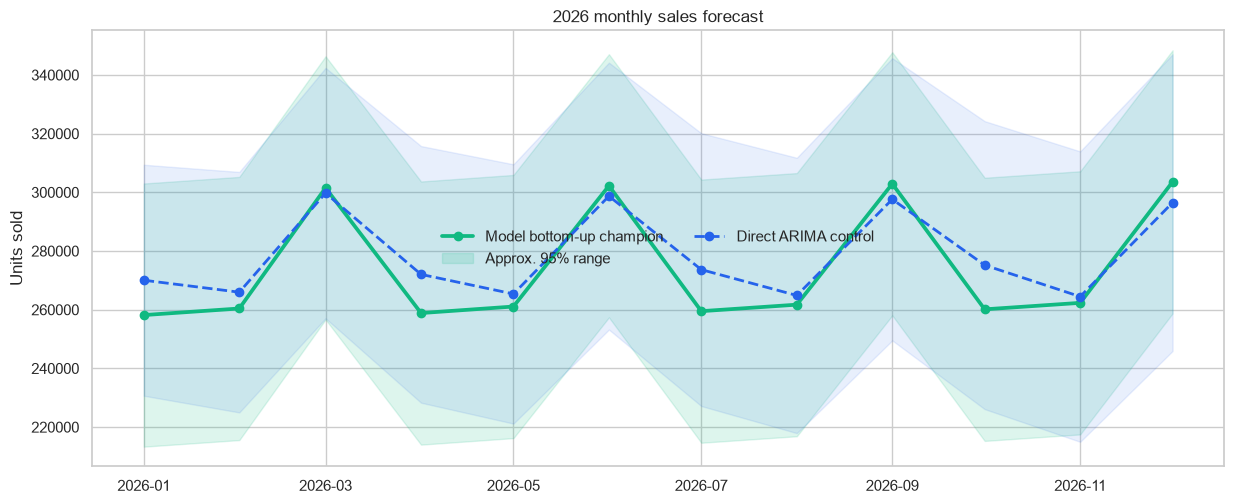

In [55]:
fig, ax = plt.subplots(figsize=(12.5, 5.2))
ax.plot(future_forecast.index, future_forecast["Forecast"], color=GREEN, lw=2.7, marker="o", label="Model bottom-up champion")
ax.fill_between(future_forecast.index, future_forecast["Lower95_Approx"], future_forecast["Upper95_Approx"], color=GREEN, alpha=.14, label="Approx. 95% range")
ax.plot(future_forecast.index, future_forecast["Direct_ARIMA"], color=BLUE, lw=2, ls="--", marker="o", label="Direct ARIMA control")
ax.fill_between(future_forecast.index, future_forecast["Direct_Lower95"], future_forecast["Direct_Upper95"], color=BLUE, alpha=.10)
ax.set(title="2026 monthly sales forecast", ylabel="Units sold")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_future_forecast.png", dpi=160, bbox_inches="tight")
plt.show()

## 18. 실행 제안

### 판매·재고 운영

- 3·6·9·12월에 반복되는 분기 말 고점 전에 물류·재고 여력을 선제 배치한다.
- 총량 예산은 차종별 bottom-up을 기준으로, 직접 ARIMA와의 월별 차이를 예측 리스크로 관리한다.
- 차종별 WAPE가 높은 모델은 현지 영업 전망과 결합해 보정한다.

### 재학습 규칙

- 실제가 근사 예측 범위를 벗어나거나 3개월 누적 WAPE가 8%를 넘으면 재학습한다.
- 최소 분기 1회 rolling-origin 다중 백테스트로 모델 순위 안정성을 확인한다.
- GDP·유가·가격의 실제 미래 시나리오가 확보되면 SARIMAX/Prophet regressor를 별도 비교한다.

## 19. 한계

1. 교육용 재구성 데이터이므로 실제 BMW 공시 수치와 일치하지 않는다.
2. 96개월은 복잡한 계절모형을 안정적으로 검증하기에 길지 않다.
3. 팬데믹·공급망·프로모션 같은 이벤트 변수가 없다.
4. 2026 근사 범위는 12개월 홀드아웃 잔차를 사용하므로 완전히 보정된 확률구간이 아니다.
5. bottom-up의 총량 개선에는 차종 간 오차 상쇄가 포함된다.

## 20. 분석 결과 저장

In [56]:
monthly.to_csv(OUTPUT_DIR / "monthly_aggregated.csv")
seasonality_table.to_csv(OUTPUT_DIR / "seasonality_evidence.csv", index=False)
final_comparison.to_csv(OUTPUT_DIR / "direct_model_comparison.csv", index=False)
hierarchy_comparison.to_csv(OUTPUT_DIR / "hierarchy_comparison.csv", index=False)
hierarchy_detail.to_csv(OUTPUT_DIR / "hierarchy_detail.csv", index=False)
future_forecast.to_csv(OUTPUT_DIR / "future_2026_forecast.csv")

manifest = {
    "selected_period": SELECTED_PERIOD,
    "best_direct_model": BEST_DIRECT_MODEL,
    "best_operational_approach": BEST_APPROACH,
    "best_operational_mae": float(hierarchy_comparison.iloc[0]["MAE"]),
    "forecast_2026_total": float(future_forecast["Forecast"].sum()),
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print("저장 완료")
for p in sorted(OUTPUT_DIR.iterdir()): print("-", p.name)

저장 완료
- 01_monthly_sales.png
- 02_seasonality_evidence.png
- 03_stl.png
- 04_direct_model_comparison.png
- 05_hierarchy_comparison.png
- 06_future_forecast.png
- direct_model_comparison.csv
- future_2026_forecast.csv
- hierarchy_comparison.csv
- hierarchy_detail.csv
- monthly_aggregated.csv
- seasonality_evidence.csv
- summary.json


## 최종 결론

- **직접 총량 챔피언:** ARIMA(3,1,3)
- **운영용 전체 챔피언:** 차종별 validation-selected Holt-Winters/계절 나이브를 합산한 model bottom-up
- **선택 근거:** 2025년 완전 홀드아웃 MAE 최소
- **주기 판단:** 월별 데이터지만 3개월 분기 패턴이 가장 강함
- **운영 원칙:** bottom-up을 기준선으로 사용하고 직접 ARIMA를 독립 통제선으로 병행

이 노트북은 데이터 검증, 누수 방지, 모델 개선 과정, 계층형 비교, 불확실성 및 한계까지 한 흐름으로 재현한다.